/home/janowczy/research/PatchSorter/ps_prototypes_v2/utils.py:462: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(
/home/janowczy/research/PatchSorter/ps_prototypes_v2/utils.py:467: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(


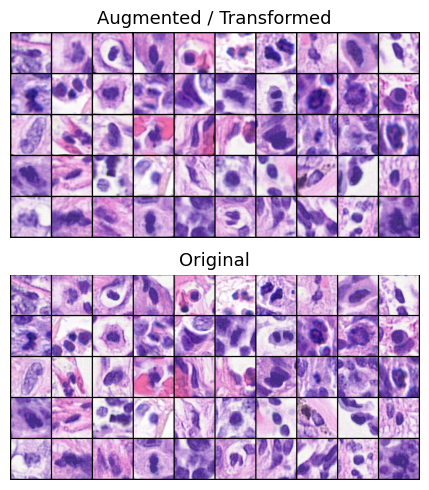

In [1]:
##
import torch
import torch.nn.functional as F
from albumentations.pytorch import ToTensorV2
from torchvision.transforms.functional import center_crop
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter
import logging

from utils import *
from patch_logging import *
import timm
from configs import *

import tables

   
class Dataset(object):
    def __init__(self, fname, nviews, transforms=None):
        self.fname = fname

        self.geom_transform, self.photo_transform = (
            transforms if transforms else (None, None)
        )

        with tables.open_file(self.fname, "r") as db:
            self.nitems = db.root.patch.shape[0]

        self.imgs = None
        self.labels = None
        self.nviews = nviews

    def __getitem__(self, index):
        with tables.open_file(self.fname, "r") as db:
            self.imgs = db.root.patch
            self.labels = db.root.tmp_label  # ps_label has all the data - here we're using just a random set created  in a noteobok

            # get the requested image and mask from the pytable
            img = self.imgs[index, :, :, :]
            label = self.labels[index]

        img_new = img

        if self.geom_transform:
            geom_out = self.geom_transform(image=img_new)
            img_geom = geom_out["image"]

            if self.photo_transform:
                anchor = ToTensorV2()(image=img_geom)["image"]
                views = tuple(
                    self.photo_transform(image=img_geom)["image"]
                    for _ in range(self.nviews - 1)
                )
                return (anchor, *views, label, img,index)

        else:
            print("no aug?")
            return img_new, label, img, index

    def __len__(self):
        return self.nitems


# Initialize dataset with proper parameters
dataset = Dataset(
    "mitosis_ps_labels.pytable", nviews=NVIEWS, transforms=get_transforms(PATCH_SIZE)
)


dataloader = DataLoader(
    InfiniteDataset(dataset),
    batch_size=BATCH_SIZE,
    shuffle=False,
    #num_workers=64,
    num_workers=8,
    pin_memory=True,
    drop_last=True,
    persistent_workers=True,
    prefetch_factor=4, #UNCOMMENT
)
# prefetcher = cuda_prefetc[her(dataloader)
vram_prefetcher = threaded_vram_prefetcher(dataloader, buffer_size=4) #UNCOMMENT
#vram_prefetcher = dataloader


#
# ------------------------


import matplotlib.pyplot as plt
import math

# obtenir un batch
batch_data = next(iter(dataloader))
*views, batch_labels, original_imgs, ids = batch_data
batch_imgs = views[0]

import torchvision.utils as vutils


def visualize_batch(batch_imgs, original_imgs, nrow=10, ntot=50):
    batch_imgs = batch_imgs[:ntot]
    original_imgs = original_imgs[:ntot].permute(
        0, 3, 1, 2
    )  # (B, H, W, C) -> (B, C, H, W)

    batch_grid = vutils.make_grid(batch_imgs, nrow=nrow, padding=2)
    original_grid = vutils.make_grid(original_imgs, nrow=nrow, padding=2)

    batch_np = batch_grid.permute(1, 2, 0).cpu().numpy()
    original_np = original_grid.permute(1, 2, 0).cpu().numpy()

    fig, axes = plt.subplots(2, 1, figsize=(20, 5))

    axes[0].imshow(batch_np)
    axes[0].set_title("Augmented / Transformed", fontsize=13)
    axes[0].axis("off")

    axes[1].imshow(original_np)
    axes[1].set_title("Original", fontsize=13)
    axes[1].axis("off")

    plt.tight_layout()
    #plt.savefig("batch_visualization.png", dpi=150, bbox_inches="tight")\
    plt.show()
    plt.close()


visualize_batch(batch_imgs, original_imgs)



In [2]:
# batch_data = next(iter(dataloader))
# *views, batch_labels, original_imgs, ids = batch_data
# batch_imgs = views[1]
# visualize_batch(batch_imgs, original_imgs)


0


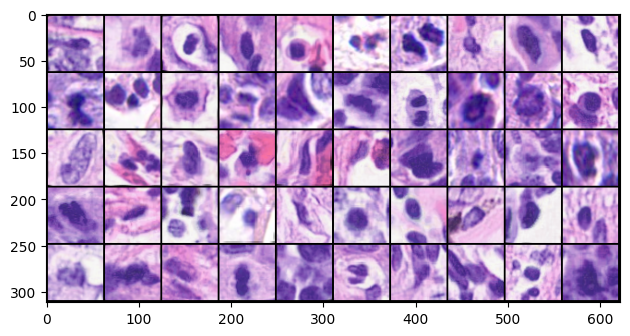

1


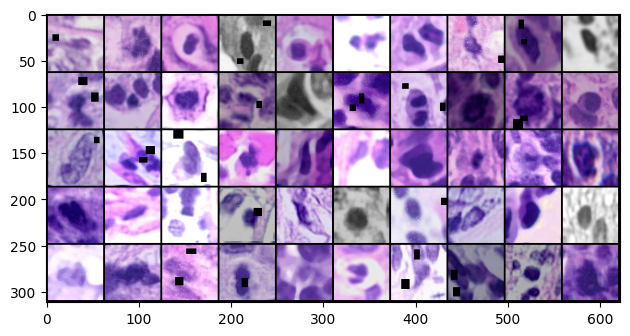

2


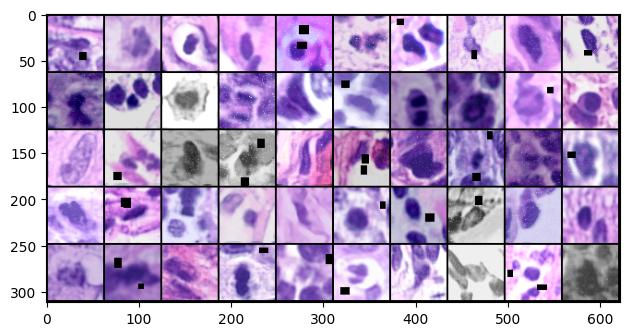

3


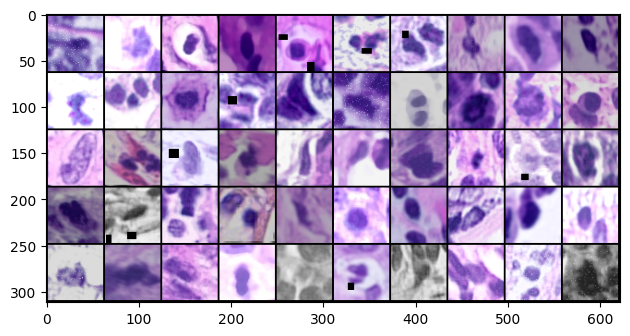

In [4]:

def visualize_batch(batch_imgs, original_imgs, nrow=10, ntot=50):
    batch_imgs = batch_imgs[:ntot]
    original_imgs = original_imgs[:ntot].permute(
        0, 3, 1, 2
    )  # (B, H, W, C) -> (B, C, H, W)

    batch_grid = vutils.make_grid(batch_imgs, nrow=nrow, padding=2)
    original_grid = vutils.make_grid(original_imgs, nrow=nrow, padding=2)

    batch_np = batch_grid.permute(1, 2, 0).cpu().numpy()
    original_np = original_grid.permute(1, 2, 0).cpu().numpy()



    plt.imshow(batch_np)
    plt.tight_layout()
    plt.show()
    plt.close()


#visualize_batch(batch_imgs, original_imgs)
for i,v in enumerate(views):
    print(i)
    batch_imgs = v
    visualize_batch(batch_imgs, original_imgs)
